In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

import os
os.makedirs('plots', exist_ok=True)

SEED = 42
np.random.seed(SEED)
print("Libraries loaded ✅")

Libraries loaded ✅


In [2]:
df = pd.read_csv('ted_main.csv')
print(f"Shape: {df.shape}")
print(f"\nColumns:\n{df.columns.tolist()}")
print(f"\nData types:\n{df.dtypes}")
print(f"\nMissing values:\n{df.isnull().sum()}")
df.head()

Shape: (2550, 17)

Columns:
['comments', 'description', 'duration', 'event', 'film_date', 'languages', 'main_speaker', 'name', 'num_speaker', 'published_date', 'ratings', 'related_talks', 'speaker_occupation', 'tags', 'title', 'url', 'views']

Data types:
comments              int64
description             str
duration              int64
event                   str
film_date             int64
languages             int64
main_speaker            str
name                    str
num_speaker           int64
published_date        int64
ratings                 str
related_talks           str
speaker_occupation      str
tags                    str
title                   str
url                     str
views                 int64
dtype: object

Missing values:
comments              0
description           0
duration              0
event                 0
film_date             0
languages             0
main_speaker          0
name                  0
num_speaker           0
published_date       

,comments,description,duration,event,film_date,languages,main_speaker,name,num_speaker,published_date,ratings,related_talks,speaker_occupation,tags,title,url,views
0,4553,Sir Ken Robinson makes an entertaining and pro...,1164,TED2006,1140825600,60,Ken Robinson,Ken Robinson: Do schools kill creativity?,1,1151367060,"[{'id': 7, 'name': 'Funny', 'count': 19645}, {...","[{'id': 865, 'hero': 'https://pe.tedcdn.com/im...",Author/educator,"['children', 'creativity', 'culture', 'dance',...",Do schools kill creativity?,https://www.ted.com/talks/ken_robinson_says_sc...,47227110
1,265,With the same humor and humanity he exuded in ...,977,TED2006,1140825600,43,Al Gore,Al Gore: Averting the climate crisis,1,1151367060,"[{'id': 7, 'name': 'Funny', 'count': 544}, {'i...","[{'id': 243, 'hero': 'https://pe.tedcdn.com/im...",Climate advocate,"['alternative energy', 'cars', 'climate change...",Averting the climate crisis,https://www.ted.com/talks/al_gore_on_averting_...,3200520
2,124,New York Times columnist David Pogue takes aim...,1286,TED2006,1140739200,26,David Pogue,David Pogue: Simplicity sells,1,1151367060,"[{'id': 7, 'name': 'Funny', 'count': 964}, {'i...","[{'id': 1725, 'hero': 'https://pe.tedcdn.com/i...",Technology columnist,"['computers', 'entertainment', 'interface desi...",Simplicity sells,https://www.ted.com/talks/david_pogue_says_sim...,1636292
3,200,"In an emotionally charged talk, MacArthur-winn...",1116,TED2006,1140912000,35,Majora Carter,Majora Carter: Greening the ghetto,1,1151367060,"[{'id': 3, 'name': 'Courageous', 'count': 760}...","[{'id': 1041, 'hero': 'https://pe.tedcdn.com/i...",Activist for environmental justice,"['MacArthur grant', 'activism', 'business', 'c...",Greening the ghetto,https://www.ted.com/talks/majora_carter_s_tale...,1697550
4,593,You've never seen data presented like this. Wi...,1190,TED2006,1140566400,48,Hans Rosling,Hans Rosling: The best stats you've ever seen,1,1151440680,"[{'id': 9, 'name': 'Ingenious', 'count': 3202}...","[{'id': 2056, 'hero': 'https://pe.tedcdn.com/i...",Global health expert; data visionary,"['Africa', 'Asia', 'Google', 'demo', 'economic...",The best stats you've ever seen,https://www.ted.com/talks/hans_rosling_shows_t...,12005869


=== Descriptive Statistics ===
       comments  duration  languages  num_speaker        views
count   2550.00   2550.00    2550.00      2550.00      2550.00
mean     191.56    826.51      27.33         1.03   1698297.48
std      282.32    374.01       9.56         0.21   2498479.37
min        2.00    135.00       0.00         1.00     50443.00
25%       63.00    577.00      23.00         1.00    755792.75
50%      118.00    848.00      28.00         1.00   1124523.50
75%      221.75   1046.75      33.00         1.00   1700759.50
max     6404.00   5256.00      72.00         5.00  47227110.00


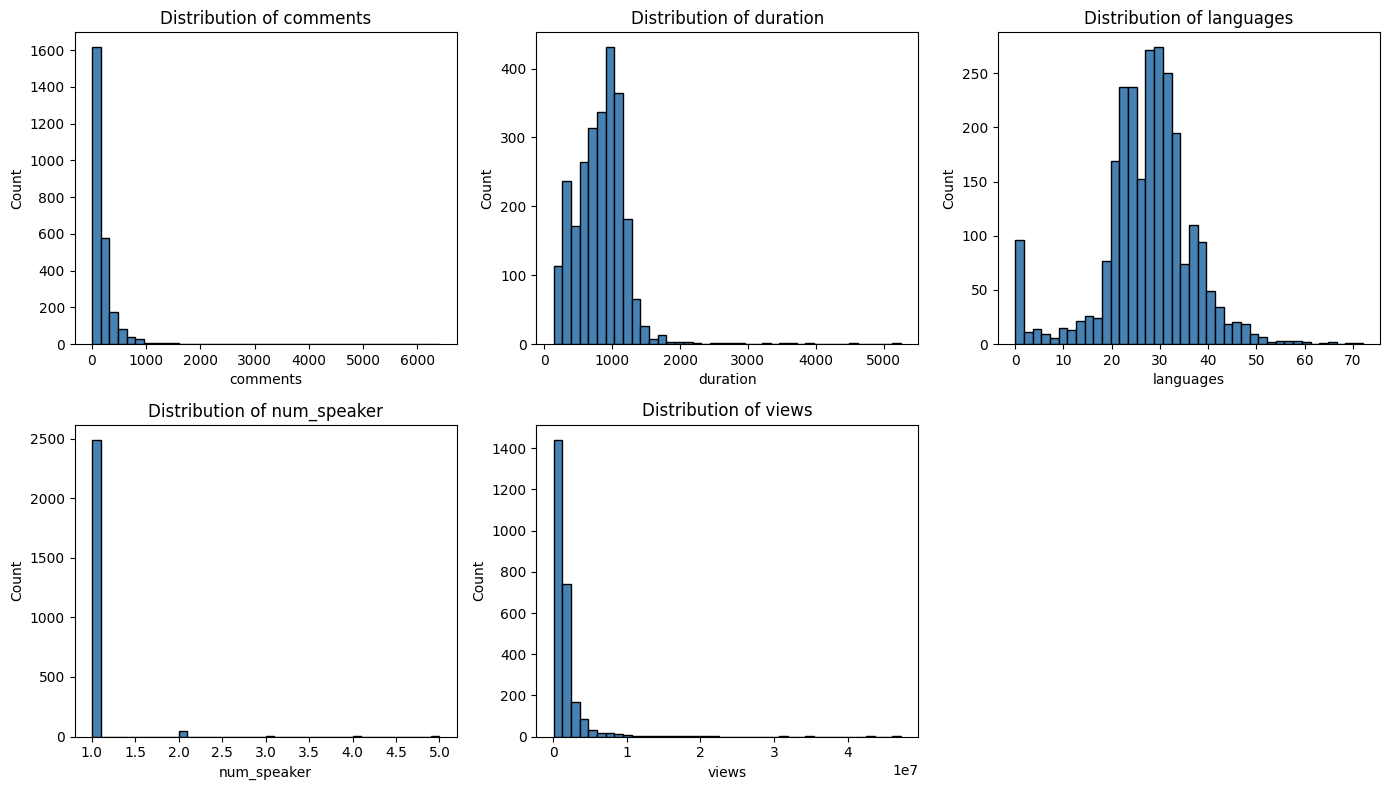

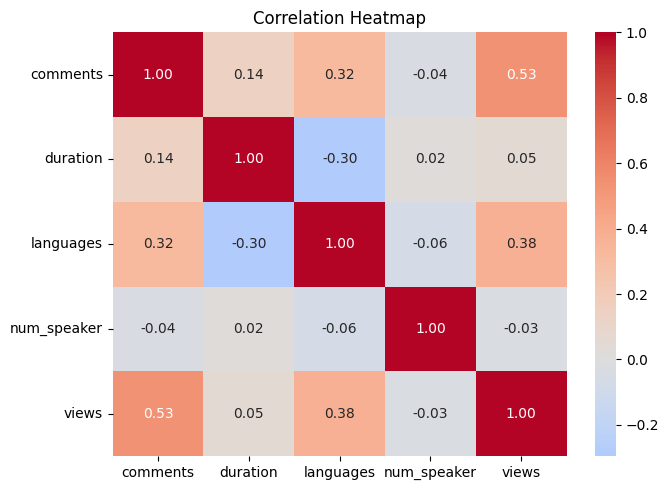

EDA plots saved ✅


In [3]:
features = ['comments', 'duration', 'languages', 'num_speaker', 'views']

print("=== Descriptive Statistics ===")
print(df[features].describe().round(2))

# Distribution plots
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()
for i, col in enumerate(features):
    axes[i].hist(df[col], bins=40, color='steelblue', edgecolor='black')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
axes[5].axis('off')
plt.tight_layout()
plt.savefig('plots/distributions.png', dpi=150)
plt.show()

# Correlation heatmap
plt.figure(figsize=(7, 5))
sns.heatmap(df[features].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.savefig('plots/correlation_heatmap.png', dpi=150)
plt.show()

print("EDA plots saved ✅")

In [4]:
features = ['comments', 'duration', 'languages', 'num_speaker', 'views']

X = df[features].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Feature matrix shape: {X_scaled.shape}")
print(f"Features used: {features}")
print(f"\nMean after scaling (should be ~0): {X_scaled.mean(axis=0).round(4)}")
print(f"Std after scaling (should be ~1):  {X_scaled.std(axis=0).round(4)}")
print("Preprocessing done ✅")

Feature matrix shape: (2550, 5)
Features used: ['comments', 'duration', 'languages', 'num_speaker', 'views']

Mean after scaling (should be ~0): [ 0.  0. -0. -0. -0.]
Std after scaling (should be ~1):  [1. 1. 1. 1. 1.]
Preprocessing done ✅


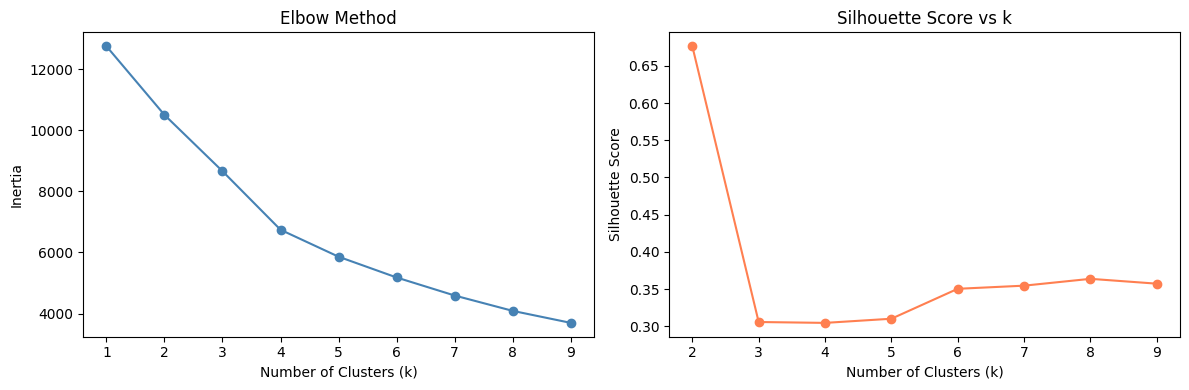

Best k by silhouette: 2
Silhouette scores: [0.6764, 0.3058, 0.3046, 0.3102, 0.3504, 0.3546, 0.3638, 0.3573]


In [5]:
inertias = []
sil_scores = []
K_range = range(2, 10)

# Elbow needs k=1 as starting point
km1 = KMeans(n_clusters=1, random_state=SEED, n_init=10)
km1.fit(X_scaled)
inertias_plot = [km1.inertia_]

for k in K_range:
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    inertias_plot.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(range(1, 10), inertias_plot, marker='o', color='steelblue')
axes[0].set_title('Elbow Method')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')

axes[1].plot(K_range, sil_scores, marker='o', color='coral')
axes[1].set_title('Silhouette Score vs k')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')

plt.tight_layout()
plt.savefig('plots/elbow_silhouette.png', dpi=150)
plt.show()

best_k = list(K_range)[np.argmax(sil_scores)]
print(f"Best k by silhouette: {best_k}")
print(f"Silhouette scores: {[round(s, 4) for s in sil_scores]}")

KMeans Silhouette Score (k=2): 0.6764
DBSCAN — clusters: 3, noise points: 52
DBSCAN Silhouette Score: 0.6296


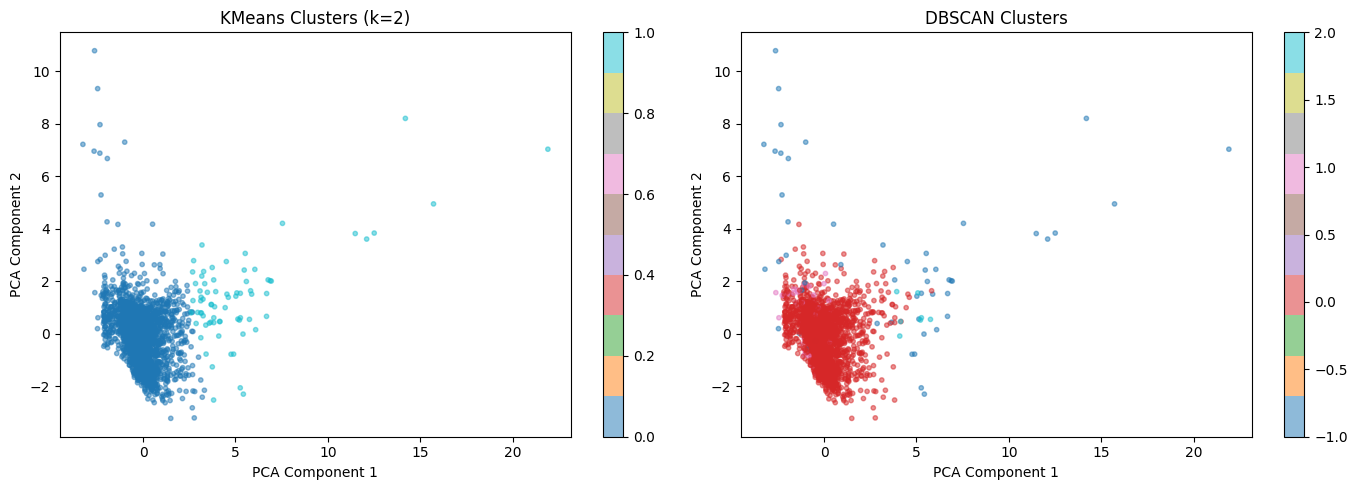

Clustering done ✅


In [6]:
# K-Means with best k
kmeans = KMeans(n_clusters=best_k, random_state=SEED, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)
km_sil = silhouette_score(X_scaled, kmeans_labels)
print(f"KMeans Silhouette Score (k={best_k}): {km_sil:.4f}")

# DBSCAN
dbscan = DBSCAN(eps=1.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scaled)
n_clusters_db = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = (dbscan_labels == -1).sum()
print(f"DBSCAN — clusters: {n_clusters_db}, noise points: {n_noise}")
if n_clusters_db > 1:
    mask = dbscan_labels != -1
    db_sil = silhouette_score(X_scaled[mask], dbscan_labels[mask])
    print(f"DBSCAN Silhouette Score: {db_sil:.4f}")
else:
    print("DBSCAN could not find multiple clusters")

# PCA visualisation
pca = PCA(n_components=2, random_state=SEED)
X_pca = pca.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sc1 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels,
                      cmap='tab10', alpha=0.5, s=10)
axes[0].set_title(f'KMeans Clusters (k={best_k})')
axes[0].set_xlabel('PCA Component 1')
axes[0].set_ylabel('PCA Component 2')
plt.colorbar(sc1, ax=axes[0])

sc2 = axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=dbscan_labels,
                      cmap='tab10', alpha=0.5, s=10)
axes[1].set_title('DBSCAN Clusters')
axes[1].set_xlabel('PCA Component 1')
axes[1].set_ylabel('PCA Component 2')
plt.colorbar(sc2, ax=axes[1])

plt.tight_layout()
plt.savefig('plots/clustering_pca.png', dpi=150)
plt.show()

print("Clustering done ✅")

=== KMeans Cluster Profiles ===
                comments  duration  languages  num_speaker        views
kmeans_cluster                                                         
0                 162.61    822.30      26.92         1.03   1408104.23
1                1174.04    969.33      41.22         1.01  11544991.66

=== DBSCAN Cluster Profiles (excluding noise) ===
                comments  duration  languages  num_speaker        views
dbscan_cluster                                                         
0                 173.99    814.70      27.27          1.0   1500916.43
1                 106.96    774.40      24.42          2.0   1190951.69
2                 489.43    870.43      40.86          1.0  15695675.43


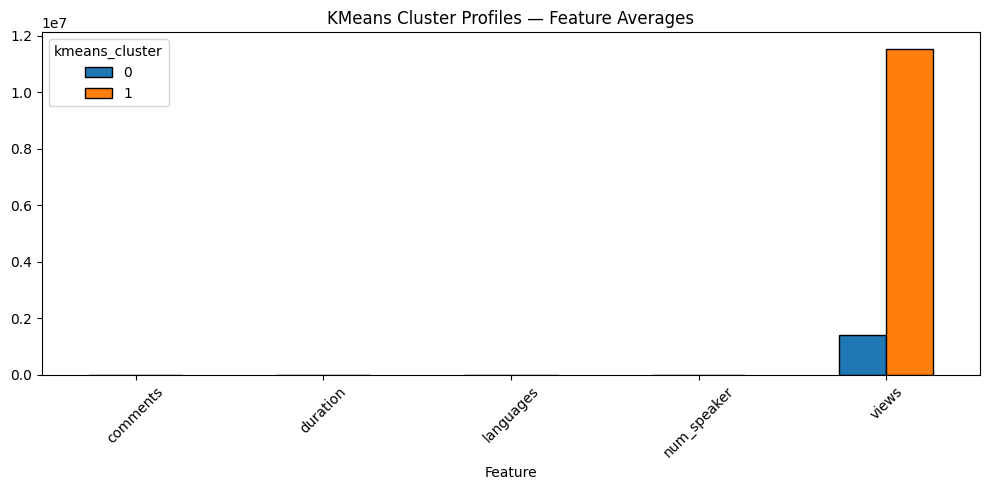


Cluster profiling done ✅


In [7]:
df_result = df[features].copy()
df_result['kmeans_cluster'] = kmeans_labels
df_result['dbscan_cluster'] = dbscan_labels

# KMeans profile
print("=== KMeans Cluster Profiles ===")
kmeans_profile = df_result.groupby('kmeans_cluster')[features].mean().round(2)
print(kmeans_profile.to_string())

# DBSCAN profile (exclude noise = -1)
print("\n=== DBSCAN Cluster Profiles (excluding noise) ===")
dbscan_profile = df_result[df_result['dbscan_cluster'] != -1].groupby('dbscan_cluster')[features].mean().round(2)
print(dbscan_profile.to_string())

# KMeans bar chart
kmeans_profile.T.plot(kind='bar', figsize=(10, 5), edgecolor='black')
plt.title('KMeans Cluster Profiles — Feature Averages')
plt.xlabel('Feature')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('plots/kmeans_profiles.png', dpi=150)
plt.show()

print("\nCluster profiling done ✅")

In [8]:
print("=" * 55)
print("CLUSTERING RESULTS SUMMARY")
print("=" * 55)

print("\n--- ALGORITHM COMPARISON ---")
results = {
    'Algorithm': ['KMeans', 'DBSCAN'],
    'Clusters Found': [best_k, n_clusters_db],
    'Noise Points': [0, n_noise],
    'Silhouette Score': [round(km_sil, 4), round(db_sil, 4)]
}
import pandas as pd
results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

print("\n--- KMEANS CLUSTER PROFILES ---")
print(kmeans_profile.to_string())

print("\n--- DBSCAN CLUSTER PROFILES ---")
print(dbscan_profile.to_string())

print("\n✅ All done. Check plots/ folder for all figures.")

CLUSTERING RESULTS SUMMARY

--- ALGORITHM COMPARISON ---
Algorithm  Clusters Found  Noise Points  Silhouette Score
   KMeans               2             0            0.6764
   DBSCAN               3            52            0.6296

--- KMEANS CLUSTER PROFILES ---
                comments  duration  languages  num_speaker        views
kmeans_cluster                                                         
0                 162.61    822.30      26.92         1.03   1408104.23
1                1174.04    969.33      41.22         1.01  11544991.66

--- DBSCAN CLUSTER PROFILES ---
                comments  duration  languages  num_speaker        views
dbscan_cluster                                                         
0                 173.99    814.70      27.27          1.0   1500916.43
1                 106.96    774.40      24.42          2.0   1190951.69
2                 489.43    870.43      40.86          1.0  15695675.43

✅ All done. Check plots/ folder for all figures.
